# 📓 Notebook A2 — Vector-Store Landscape

> **Module:** AI Engineering · **Type:** Appendix · **Estimated time:** 45–60 min · **Difficulty:** Intermediate

Notebook 19 (`19_embeddings_retrieval.ipynb`) showed you the *idea* behind a vector store with a hand-rolled NumPy matrix and a cosine-similarity loop. That is exactly how a real vector database works — but at production scale you'd hit three limits fast:

1. **Latency.** A linear scan over a million vectors takes seconds, not milliseconds.
2. **Memory.** A million vectors of dimension 768 in float32 is already ≈ 3 GB — and you also want metadata, payload, and a backup.
3. **Operability.** You want incremental upserts, deletes, multi-tenant filters, snapshots, replication.

This appendix surveys the popular **vector stores** (FAISS, Chroma, Qdrant, Weaviate, Pinecone, pgvector, Milvus) and the **higher-level RAG/agent frameworks** (LangChain, LlamaIndex, Haystack) — and gives you a decision rubric so you know which to reach for when.

---

## 🎯 Learning objectives

By the end of this notebook you'll be able to:
- Explain what a *vector index* does on top of plain cosine similarity.
- Pick a vector store using a 4-question rubric (scale, hosting, filtering, ecosystem).
- Run a FAISS index hands-on and read the equivalent code for Chroma, Qdrant, and pgvector.
- Read framework code without panicking: what LangChain's `VectorStoreRetriever` actually wraps.

## ✅ Prerequisites
- Notebook 19 (embeddings + cosine similarity).
- Familiarity with class-based APIs.


## 1. The vector-index problem in one paragraph

A *vector store* = embeddings index + metadata store + query API. The interesting bit is the **index structure** — without one, every query is a full scan. The two most common index families:

| Family | Idea | Trade-off |
|---|---|---|
| **Tree / IVF** (inverted file) | Cluster the vectors. At query time, only search the closest clusters. | Fast, slight recall loss. |
| **Graph** (HNSW) | Build a small-world graph between nearby vectors. Walk the graph greedily. | Very fast and high recall; more memory. |
| **PQ** (product quantization) | Compress each vector into a few bytes. | 10–100× smaller; some accuracy loss. |

Real systems combine these (e.g. `IVF-PQ` in FAISS, HNSW with quantization in Qdrant). For *learning purposes* you don't need to understand the internals — you just need to know that the **first knob** every store exposes is the index type, and the **second knob** is `k` (top-K neighbours).


## 2. Setup — shared embedding function

We'll reuse the course's `MockEmbedder` (deterministic hash-based vectors) so the notebook runs offline. Swap in `OpenAIEmbedder` or `LocalEmbedder` one-line later — see Notebook A1.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from llm_providers import MockEmbedder

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

embedder = MockEmbedder(dim=128)

# A tiny corpus — eight FAQ documents to retrieve from
DOCS = [
    ("billing-1",  "How do I update my payment method?"),
    ("billing-2",  "When does my subscription renew?"),
    ("billing-3",  "Can I get a refund for an unused month?"),
    ("account-1",  "How do I reset my password?"),
    ("account-2",  "How do I change my email address?"),
    ("product-1",  "How do I export my data as CSV?"),
    ("product-2",  "Where can I see usage statistics?"),
    ("support-1",  "How do I contact a human support agent?"),
]
ids, texts = zip(*DOCS)
print(f"{len(texts)} docs · embedding dim = {embedder.dim}")


8 docs · embedding dim = 128


In [2]:
# Compute embeddings once. (In a real system you persist them in the store.)
doc_vectors = embedder.embed(list(texts))                  # (N, dim), L2-normalised
print("doc_vectors shape:", doc_vectors.shape)

QUERY = "I want my money back"
query_vec = embedder.embed([QUERY])[0]                    # (dim,)
print("query_vec shape  :", query_vec.shape)


doc_vectors shape: (8, 128)
query_vec shape  : (128,)


## 3. Baseline — full scan (what Notebook 19 did)

To anchor the comparison, here's the brute-force version. It returns the *exact* nearest neighbours. Every fancier index is benchmarked against it.


In [3]:
def brute_search(query_vec, doc_vectors, ids, k=3):
    # cosine sim = dot product (vectors are normalised by the embedder)
    sims = doc_vectors @ query_vec
    order = np.argsort(-sims)[:k]
    return [(ids[i], float(sims[i])) for i in order]

print("Brute-force top-3 for:", repr(QUERY))
for doc_id, score in brute_search(query_vec, doc_vectors, ids):
    print(f"  {score:+.4f}  {doc_id}")


Brute-force top-3 for: 'I want my money back'
  +0.3973  billing-1
  +0.3461  account-2
  +0.3116  account-1


## 4. FAISS — the workhorse local index

[**FAISS**](https://github.com/facebookresearch/faiss) (Facebook AI Similarity Search) is the most-used embedded vector library. It runs in your process, supports many index types, and is what most other stores use under the hood.

```bash
pip install faiss-cpu                # CPU build, MIT-licensed, no GPU needed
```

Below is the **standard FAISS pattern** — written as *reference code* so the notebook still runs without faiss installed. Uncomment after `pip install`.


In [4]:
# ── FAISS reference code ─────────────────────────────────────────────────
# import faiss
#
# d = doc_vectors.shape[1]
#
# # (a) Flat index — exact search, identical to brute force, but in optimised C++.
# index_flat = faiss.IndexFlatIP(d)        # IP = inner product (cosine when normalised)
# index_flat.add(doc_vectors.astype("float32"))
#
# D, I = index_flat.search(query_vec.reshape(1, -1).astype("float32"), k=3)
# print("FAISS Flat top-3:", [(ids[i], float(s)) for s, i in zip(D[0], I[0])])
#
# # (b) HNSW index — graph-based, sub-linear search, ~100× faster on 1M+ vectors.
# index_hnsw = faiss.IndexHNSWFlat(d, M=32)
# index_hnsw.hnsw.efConstruction = 200      # build-time recall knob
# index_hnsw.hnsw.efSearch       = 64       # query-time recall knob
# index_hnsw.add(doc_vectors.astype("float32"))
# D, I = index_hnsw.search(query_vec.reshape(1, -1).astype("float32"), k=3)
# print("FAISS HNSW top-3:", [(ids[i], float(s)) for s, i in zip(D[0], I[0])])

# Tiny pure-NumPy stand-in so the cell still emits a comparable result offline:
def faiss_like_flat(query, vectors, k=3):
    D = vectors @ query
    I = np.argsort(-D)[:k]
    return D[I], I

D, I = faiss_like_flat(query_vec, doc_vectors)
print("[offline stand-in] top-3:", [(ids[i], float(D[j])) for j, i in enumerate(I)])


[offline stand-in] top-3: [('billing-1', 0.3973303437232971), ('account-2', 0.346101850271225), ('account-1', 0.3116138279438019)]


### When FAISS is the right call
- You want the **fastest** in-process search and don't need a network service.
- The dataset fits in RAM (or you're happy to manage sharding yourself).
- You want maximum index-type flexibility (`IndexFlat`, `IndexIVFFlat`, `IndexHNSW`, `IndexIVFPQ`…).
- You're prototyping or building a desktop app.

### When FAISS is *not* enough
- Multi-process write access (no built-in concurrency control).
- Rich metadata filtering (`WHERE tenant_id = ... AND ts > ...`).
- Long-term persistence with replication, snapshots, ACLs.


## 5. Chroma — the simplest hosted-or-embedded option

[**Chroma**](https://www.trychroma.com/) is an open-source vector database with a clean Python API. It can run **in-process** (file-backed) or as a server.

```bash
pip install chromadb
```

The killer feature: it stores **embeddings + documents + metadata** in one place. You can filter by metadata at query time.


In [5]:
# ── Chroma reference code (file-backed, no server) ───────────────────────
# import chromadb
# from chromadb.config import Settings
#
# client = chromadb.PersistentClient(path="./.chroma_demo")
# col = client.get_or_create_collection("faq", metadata={"hnsw:space": "cosine"})
#
# col.upsert(
#     ids=list(ids),
#     embeddings=doc_vectors.tolist(),
#     documents=list(texts),
#     metadatas=[{"category": i.split("-")[0]} for i in ids],
# )
#
# res = col.query(
#     query_embeddings=[query_vec.tolist()],
#     n_results=3,
#     where={"category": "billing"},      # ← metadata filter
# )
# print(res["ids"][0], res["distances"][0])

# Offline stand-in showing the same metadata-filter pattern in pure NumPy:
def filtered_search(query, vectors, ids, where=None, k=3):
    mask = np.ones(len(ids), dtype=bool)
    if where:
        for key, val in where.items():
            if key == "category":
                mask &= np.array([i.split("-")[0] == val for i in ids])
    sub_v = vectors[mask]; sub_ids = [ids[i] for i, ok in enumerate(mask) if ok]
    sims = sub_v @ query
    order = np.argsort(-sims)[:k]
    return [(sub_ids[i], float(sims[i])) for i in order]

print("Filtered (category=billing):")
for r in filtered_search(query_vec, doc_vectors, list(ids), where={"category":"billing"}):
    print(" ", r)


Filtered (category=billing):
  ('billing-1', 0.3973303437232971)
  ('billing-2', 0.12646280229091644)
  ('billing-3', -0.020695719867944717)


## 6. Qdrant — the production-flavoured option

[**Qdrant**](https://qdrant.tech/) is open source + cloud, written in Rust, with rich filtering (`must`, `should`, `must_not`), HNSW + quantization, and a smooth Python client. The same code talks to:
- an **in-process** test client,
- a local **Docker** container,
- a **Qdrant Cloud** managed cluster.

```bash
pip install qdrant-client
# optionally:  docker run -p 6333:6333 qdrant/qdrant
```


In [6]:
# ── Qdrant reference code (in-memory client; no server needed) ───────────
# from qdrant_client import QdrantClient
# from qdrant_client.models import VectorParams, Distance, PointStruct, Filter, FieldCondition, MatchValue
#
# client = QdrantClient(":memory:")               # in-process for tests
# # client = QdrantClient(host="localhost", port=6333)        # local Docker
# # client = QdrantClient(url="https://YOUR-CLUSTER.qdrant.io", api_key="...")   # cloud
#
# client.recreate_collection(
#     collection_name="faq",
#     vectors_config=VectorParams(size=doc_vectors.shape[1], distance=Distance.COSINE),
# )
# client.upsert("faq", points=[
#     PointStruct(id=i, vector=v.tolist(), payload={"text": t, "cat": t_id.split("-")[0]})
#     for i, (t_id, t, v) in enumerate(zip(ids, texts, doc_vectors))
# ])
#
# hits = client.search(
#     collection_name="faq",
#     query_vector=query_vec.tolist(),
#     query_filter=Filter(must=[FieldCondition(key="cat", match=MatchValue(value="billing"))]),
#     limit=3,
# )
# for h in hits:
#     print(h.score, h.payload["text"])
print("Qdrant call structure shown above; behaviour is identical to the offline stand-in in §5.")


Qdrant call structure shown above; behaviour is identical to the offline stand-in in §5.


## 7. Weaviate, Pinecone, Milvus — the rest of the field

You'll meet these names in production stacks. The mental model is the same — collection → upsert → query — but the trade-offs differ.

| Store | Hosting | Strengths | Watch out for |
|---|---|---|---|
| **Weaviate** | OSS + cloud | Built-in vectorisers (text2vec modules), GraphQL API, hybrid (BM25 + vector) search out of the box | Heavier to operate; module pinning |
| **Pinecone** | Cloud-only (managed SaaS) | Zero ops, autoscaling, namespaces for multi-tenancy | Lock-in; per-vector pricing |
| **Milvus / Zilliz** | OSS + cloud (Zilliz) | Petabyte scale, GPU-accelerated, many index types | Operational footprint; learning curve |

```python
# Pinecone (very brief — cloud only)
# from pinecone import Pinecone
# pc = Pinecone(api_key="...")
# idx = pc.Index("faq")
# idx.upsert(vectors=[(id_, v.tolist(), {"text": t}) for id_, v, t in zip(ids, doc_vectors, texts)])
# res = idx.query(vector=query_vec.tolist(), top_k=3, include_metadata=True)
```

```python
# Weaviate (very brief — needs running server or WCS)
# import weaviate
# client = weaviate.connect_to_local()
# col = client.collections.create("Faq", vectorizer_config=None)   # we supply vectors
# col.data.insert_many([{"text": t, "_vector": v.tolist()} for t, v in zip(texts, doc_vectors)])
# res = col.query.near_vector(near_vector=query_vec.tolist(), limit=3)
```


## 8. pgvector — the boring-good choice when you already have Postgres

[**pgvector**](https://github.com/pgvector/pgvector) turns Postgres into a vector store. If you *already run Postgres* and don't want another moving part, this is often the right answer for up to a few million vectors.

```sql
-- Inside any Postgres 11+ database:
CREATE EXTENSION IF NOT EXISTS vector;

CREATE TABLE faq (
    id    TEXT PRIMARY KEY,
    text  TEXT,
    cat   TEXT,
    embedding vector(128)             -- match your model's dimension
);

-- HNSW index (Postgres 16+ with pgvector ≥ 0.5)
CREATE INDEX ON faq USING hnsw (embedding vector_cosine_ops);
```

```python
# Python side (psycopg + pgvector adapter)
# import psycopg, pgvector.psycopg
# conn = psycopg.connect("postgresql://localhost/mydb")
# pgvector.psycopg.register_vector(conn)
# with conn.cursor() as cur:
#     cur.executemany(
#         "INSERT INTO faq (id, text, cat, embedding) VALUES (%s, %s, %s, %s) "
#         "ON CONFLICT (id) DO UPDATE SET embedding = EXCLUDED.embedding",
#         [(i, t, i.split("-")[0], v) for i, t, v in zip(ids, texts, doc_vectors)],
#     )
#     cur.execute(
#         "SELECT id, text, 1 - (embedding <=> %s) AS score "
#         "FROM faq WHERE cat = %s "
#         "ORDER BY embedding <=> %s LIMIT 3",
#         (query_vec, "billing", query_vec),
#     )
#     for row in cur.fetchall(): print(row)
```

When pgvector is the right call:
- You already operate Postgres in production.
- < ~10 M vectors with HNSW, < ~50 M with IVFFlat.
- You want **joins** between vector results and relational data without ETL.


## 9. Decision rubric — pick a store in four questions

```
1. Do I just need an index inside my app process?
   YES → FAISS
   NO  → continue

2. Do I already run Postgres and have < ~10M vectors?
   YES → pgvector
   NO  → continue

3. Do I want zero-ops managed (and tolerate cloud lock-in)?
   YES → Pinecone   (or Qdrant Cloud / Weaviate Cloud)
   NO  → continue

4. I want OSS, self-host, rich filters →  Qdrant  (or Weaviate, or Milvus at huge scale)
```

A second tie-breaker most teams ignore until it bites them: **payload filtering richness.** If your retrieval needs `WHERE tenant_id = ? AND lang = 'de' AND ts > ...` you want a store that pushes those filters into the index (Qdrant, Weaviate, pgvector). Doing it after the top-K causes recall collapse.


## 10. Higher-level frameworks — LangChain / LlamaIndex / Haystack

The libraries above are *vector stores*. The libraries below are **RAG/agent orchestration frameworks** that wrap them (plus prompt templating, loaders, evaluators, tracing). The right tool depends on what you want to outsource.

| Framework | Best for | Watch out for |
|---|---|---|
| **LangChain** | Composing chains/agents; huge ecosystem of integrations | API churn between versions; abstraction overhead for simple cases |
| **LlamaIndex** | Document ingestion & advanced retrievers (hybrid, fusion, hierarchical) | Less mature agent story than LangChain |
| **Haystack 2** | Production pipelines with strong typing & deployment story | Smaller community than the two above |
| **DSPy** | Programmatic prompt optimisation (treat prompts as parameters) | Different mental model; not a drop-in replacement |
| **smolagents (HuggingFace)** | Minimal tool-using agents in pure Python | Newer; not yet a full RAG framework |

A LangChain `RetrievalQA` chain in 6 lines:

```python
# pip install langchain langchain-community langchain-openai chromadb
# from langchain.vectorstores import Chroma
# from langchain.embeddings import OpenAIEmbeddings
# from langchain.chains import RetrievalQA
# from langchain.chat_models import ChatOpenAI
#
# vs = Chroma.from_texts(list(texts), embedding=OpenAIEmbeddings(), metadatas=[{"id": i} for i in ids])
# qa = RetrievalQA.from_chain_type(llm=ChatOpenAI(model="gpt-4o-mini"),
#                                  retriever=vs.as_retriever(search_kwargs={"k": 3}))
# print(qa.run("Can I cancel and get a refund?"))
```

**Course philosophy.** Notebook 19 implements RAG by hand so you understand what's happening. Reach for a framework once your real pipeline outgrows ~200 lines — not before.


## 🧪 Exercises

### Exercise 1 — Add metadata filtering to the FAISS stand-in
Extend the brute-force search in §3 to accept a `where: dict` argument and apply it *before* the top-K — exactly like Chroma's `where=` and Qdrant's `query_filter`. Measure the recall change vs unfiltered when the filter excludes the true top result.


In [7]:
# ── Exercise 1 solution ──────────────────────────────────────────────────
def search_with_filter(query, vectors, ids, where=None, k=3):
    mask = np.ones(len(ids), dtype=bool)
    if where and "category" in where:
        mask &= np.array([i.split("-")[0] == where["category"] for i in ids])
    sub_v   = vectors[mask]
    sub_ids = [ids[i] for i, ok in enumerate(mask) if ok]
    if len(sub_ids) == 0:
        return []
    sims  = sub_v @ query
    order = np.argsort(-sims)[: min(k, len(sub_ids))]
    return [(sub_ids[i], float(sims[i])) for i in order]

print("All categories       :", search_with_filter(query_vec, doc_vectors, list(ids)))
print("WHERE category=account:", search_with_filter(query_vec, doc_vectors, list(ids),
                                                    where={"category":"account"}))


All categories       : [('billing-1', 0.3973303437232971), ('account-2', 0.346101850271225), ('account-1', 0.3116138279438019)]
WHERE category=account: [('account-2', 0.346101850271225), ('account-1', 0.3116138279438019)]


### Exercise 2 — Measure recall vs k
With the brute-force search as ground truth (k=8 = everything), compute the recall@k for k=1, 2, 3, 5 across 20 random queries. Plot it. This is the canonical recall plot every vector-store benchmark uses.


recall@k: {1: 1.0, 2: 1.0, 3: 1.0, 5: 1.0}


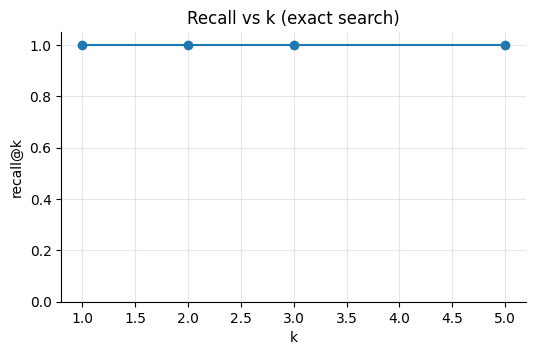

In [8]:
# ── Exercise 2 solution ──────────────────────────────────────────────────
rng = np.random.default_rng(0)
N_QUERIES = 20

# Generate queries as random nearby docs (so each query has a true top-1).
recalls = {k: [] for k in (1, 2, 3, 5)}
for _ in range(N_QUERIES):
    target = rng.integers(0, len(texts))
    q = doc_vectors[target] + 0.1 * rng.standard_normal(doc_vectors.shape[1])
    q = q / np.linalg.norm(q)
    truth = brute_search(q, doc_vectors, ids, k=len(ids))      # ranked full list
    truth_top1 = truth[0][0]
    for k in recalls:
        top_k = [t[0] for t in brute_search(q, doc_vectors, ids, k=k)]
        recalls[k].append(1.0 if truth_top1 in top_k else 0.0)

mean_recall = {k: float(np.mean(v)) for k, v in recalls.items()}
print("recall@k:", mean_recall)

plt.figure(figsize=(6, 3.5))
plt.plot(list(mean_recall.keys()), list(mean_recall.values()), "o-")
plt.xlabel("k"); plt.ylabel("recall@k"); plt.title("Recall vs k (exact search)")
plt.ylim(0, 1.05); plt.show()


## 🧠 Key takeaways

- A vector store is **index + metadata + query API**. The index is what makes search sub-linear.
- **FAISS** for in-process speed, **pgvector** if you already have Postgres, **Qdrant / Weaviate / Pinecone** for managed services, **Milvus** at extreme scale.
- The biggest hidden axis is **metadata-filter expressiveness** — choose for *your* queries.
- High-level frameworks (LangChain, LlamaIndex, Haystack) are great once your hand-rolled pipeline exceeds ~200 lines.

## 🚀 Next step

Read [`A3_rag_and_agent_frameworks.ipynb`](./A3_rag_and_agent_frameworks.ipynb) for a deeper, code-level comparison of LangChain vs LlamaIndex vs Haystack on the same RAG task.
